In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# --- 1. Load Data ---
truth = pd.read_csv("mc_truth_100_noisy.csv")
# Output from your C++ code
fit_results = pd.read_csv("mc_test_output.csv") 

hits = pd.read_csv("mc_hits_100_noisy.csv")

In [4]:
def double_exp_integral(t0, t1, A_fast, rate_fast, A_slow, rate_slow):
    """
    Integral of A_fast * exp(-rate_fast * t) + A_slow * exp(-rate_slow * t)
    over [t0, t1], with support only for t >= 0.
    """
    a = max(t0, 0.0)
    b = max(t1, 0.0)
    if b <= a:
        return 0.0

    fast = A_fast / rate_fast * (np.exp(-rate_fast * a) - np.exp(-rate_fast * b))
    slow = A_slow / rate_slow * (np.exp(-rate_slow * a) - np.exp(-rate_slow * b))
    return fast + slow

def build_unit_template_on_bins(bin_edges_us,
                                pulse_time_us,
                                A_fast, rate_fast,
                                A_slow, rate_slow,
                                support_end_us=100.0):
    """
    Unit-area expected contribution on histogram bins for one pulse.
    """
    vals = np.zeros(len(bin_edges_us) - 1, dtype=float)

    # first compute raw integrals
    for i in range(len(vals)):
        left = bin_edges_us[i] - pulse_time_us
        right = bin_edges_us[i + 1] - pulse_time_us

        # optional finite support
        if left >= support_end_us:
            continue
        right_clip = min(right, support_end_us)

        vals[i] = double_exp_integral(left, right_clip,
                                      A_fast, rate_fast,
                                      A_slow, rate_slow)

    s = vals.sum()
    if s > 0:
        vals /= s
    return vals

def build_mu_expected(bin_edges_us, pulses_df,
                      A_fast, rate_fast,
                      A_slow, rate_slow,
                      support_end_us=100.0,
                      background_per_bin=0.0):
    mu = np.zeros(len(bin_edges_us) - 1, dtype=float)

    for _, row in pulses_df.iterrows():
        comp = build_unit_template_on_bins(
            bin_edges_us=bin_edges_us,
            pulse_time_us=row['time_us'],
            A_fast=A_fast,
            rate_fast=rate_fast,
            A_slow=A_slow,
            rate_slow=rate_slow,
            support_end_us=support_end_us
        )
        mu += row['amplitude_pe'] * comp

    mu += background_per_bin
    return mu

def find_coincidence_seeds_from_hits(hits, coincidence_window_us=0.05, veto_window_us=0.01):
    """
    Mimic the C++ seed finder:
    - a seed starts at hit i
    - look forward within coincidence_window_us
    - require at least one hit from a different channel
    - require total >= 2 hits
    - after accepting a seed, veto later seeds until t0 + veto_window_us
    """
    df = hits.sort_values('time_us').reset_index(drop=True)

    times = df['time_us'].to_numpy()
    chans = df['channel'].to_numpy()

    seeds = []
    next_allowed_seed_time_us = -1e99
    n = len(df)

    for i in range(n):
        t0 = times[i]
        if t0 < next_allowed_seed_time_us:
            continue

        ch0 = chans[i]
        armed = False
        total = 1

        j = i + 1
        while j < n:
            tj = times[j]
            if tj - t0 > coincidence_window_us:
                break

            if chans[j] != ch0:
                armed = True
            total += 1
            j += 1

        if armed and total >= 2:
            seeds.append(t0)
            next_allowed_seed_time_us = t0 + veto_window_us

    return np.array(seeds)

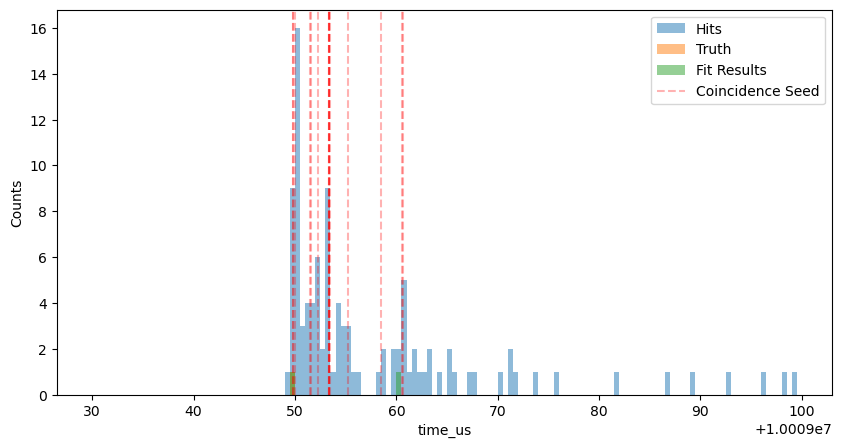

In [29]:
t0 = 10e6
tmin = 9030 + t0
tmax = 9100 + t0
bins = np.arange(tmin, tmax, 0.5)

hits_win = hits[(hits['time_us'] > tmin) & (hits['time_us'] < tmax)]
truth_win = truth[(truth['time_us'] > tmin) & (truth['time_us'] < tmax)]
fit_win = fit_results[(fit_results['time_us'] > tmin) & (fit_results['time_us'] < tmax)]

# coincidence_seeds should be a 1D array / series of seed times in absolute us
coincidence_seeds = find_coincidence_seeds_from_hits(
    hits_win,
    coincidence_window_us=0.05,
    veto_window_us=0.01
)

plt.figure(figsize=(10, 5))
plt.hist(hits_win['time_us'], bins=bins, alpha=0.5, label='Hits')
plt.hist(truth_win['time_us'], bins=bins, alpha=0.5, label='Truth')
plt.hist(fit_win['time_us'], bins=bins, alpha=0.5, label='Fit Results')

for i, s in enumerate(coincidence_seeds):
    plt.axvline(s, linestyle='--', alpha=0.3, color='red',
                label='Coincidence Seed' if i == 0 else None)

plt.legend()
plt.xlabel('time_us')
plt.ylabel('Counts')
plt.show()

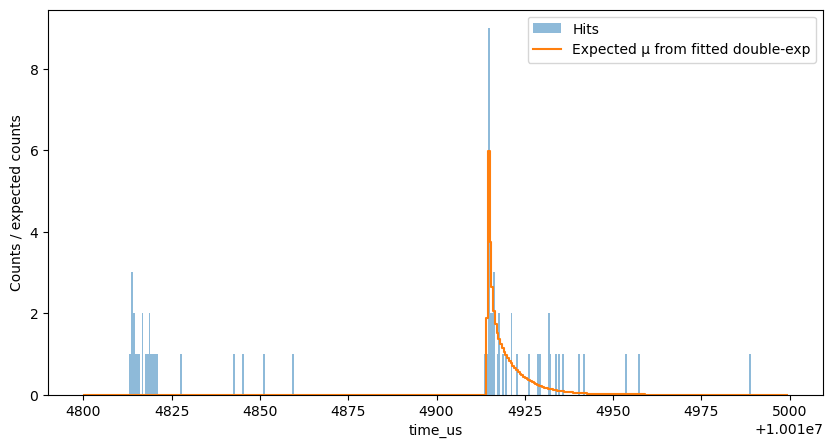

In [43]:
t0 = 10e6
tmin = 14800 + t0
tmax = 15000 + t0
bins = np.arange(tmin, tmax, 0.5)

hits_win = hits[(hits['time_us'] > tmin) & (hits['time_us'] < tmax)]
fit_win = fit_results[(fit_results['time_us'] > tmin) & (fit_results['time_us'] < tmax)]

# histogram observed hits
obs_counts, bin_edges = np.histogram(hits_win['time_us'], bins=bins)

# template params: use the same values as config/default.json or your actual run config
A_slow = 0.04136345
rate_slow = 0.15729156
A_fast = 0.12074081
rate_fast = 1.54832358
support_end_us = 100.0

mu = build_mu_expected(
    bin_edges_us=bin_edges,
    pulses_df=fit_win[['time_us', 'amplitude_pe']],
    A_fast=A_fast,
    rate_fast=rate_fast,
    A_slow=A_slow,
    rate_slow=rate_slow,
    support_end_us=support_end_us,
    background_per_bin=0.0
)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure(figsize=(10, 5))
plt.hist(hits_win['time_us'], bins=bin_edges, alpha=0.5, label='Hits')
plt.step(bin_centers, mu, where='mid', label='Expected μ from fitted double-exp')
plt.legend()
plt.xlabel('time_us')
plt.ylabel('Counts / expected counts')
plt.show()

first nonzero index = 0
first nonzero time = 0.25


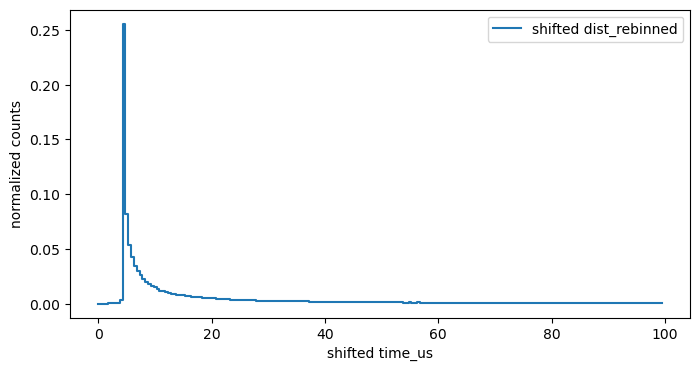

[1.63009064e-04 1.42110466e-04 1.52559765e-04 1.94356961e-04
 2.52873035e-04 2.38244016e-04 3.34377567e-04 4.99476490e-04
 3.06791417e-03 2.55759131e-01 8.18201007e-02 5.39852581e-02
 4.24387828e-02 3.44367096e-02 3.00062069e-02 2.63280537e-02
 2.28609763e-02 1.98850159e-02 1.79038288e-02 1.63280745e-02
 1.49989237e-02 1.35381117e-02 1.20459518e-02 1.14315331e-02
 1.06645545e-02 1.01274605e-02 9.21210196e-03 8.80666916e-03
 8.31137239e-03 7.92683819e-03 7.59873020e-03 7.09089427e-03
 6.79831390e-03 6.42840872e-03 6.02088606e-03 5.90385391e-03
 5.84742770e-03 5.56111690e-03 5.20375088e-03 5.00312434e-03
 4.93624883e-03 4.93624883e-03 4.53290589e-03 4.40124472e-03
 4.17762972e-03 3.97700318e-03 3.95610458e-03 3.83698258e-03
 3.81190426e-03 3.76174762e-03 3.64471548e-03 3.41901062e-03
 3.39393230e-03 3.18076660e-03 3.13269983e-03 3.04492572e-03
 2.95506174e-03 2.85474847e-03 2.89445581e-03 2.86728763e-03
 2.63322334e-03 2.53708979e-03 2.52246077e-03 2.48275343e-03
 2.39497932e-03 2.445135

In [ ]:
test_df = pd.DataFrame({
    'time_us': [4.5],
    'amplitude_pe': [100]})

csv_path = "./2022_epoch_2_tail_response.csv"
df = pd.read_csv(csv_path)

dist = np.asarray(df["Segment_12"].values)
dist = dist / np.sum(dist)

factor = 50
dist_rebinned = dist.reshape(-1, factor).sum(axis=1)
dist_rebinned = dist_rebinned / dist_rebinned.sum()

mu = build_mu_expected(
    bin_edges_us=bin_edges,
    pulses_df=test_df,
    A_fast=A_fast,
    rate_fast=rate_fast,
    A_slow=A_slow,
    rate_slow=rate_slow,
    support_end_us=support_end_us,
    background_per_bin=0.0
)

bin_edges = np.arange(0, 100.5, 0.5)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

threshold = 0.00 * np.max(dist_rebinned)
first_idx = np.argmax(dist_rebinned > threshold)

print("first nonzero index =", first_idx)
print("first nonzero time =", bin_centers[first_idx])

# shift so onset is at t=0
t_shifted = bin_centers[first_idx:] - bin_centers[first_idx]
y_shifted = dist_rebinned[first_idx:].copy()

# renormalize after truncation
y_shifted = y_shifted / y_shifted.sum()

plt.figure(figsize=(8,4))
plt.step(t_shifted, y_shifted, where='mid', label='shifted dist_rebinned')
plt.xlabel("shifted time_us")
plt.ylabel("normalized counts")
plt.legend()
plt.show()
print(dist_rebinned)

Optimized no-offset parameters: [ 9.99980789e+00 -1.22405582e+00  9.99989202e+00 -1.22394985e+00
  9.19056555e-02 -2.19449338e-01  6.47490901e-03 -3.06558135e-02
  4.50000000e+00]


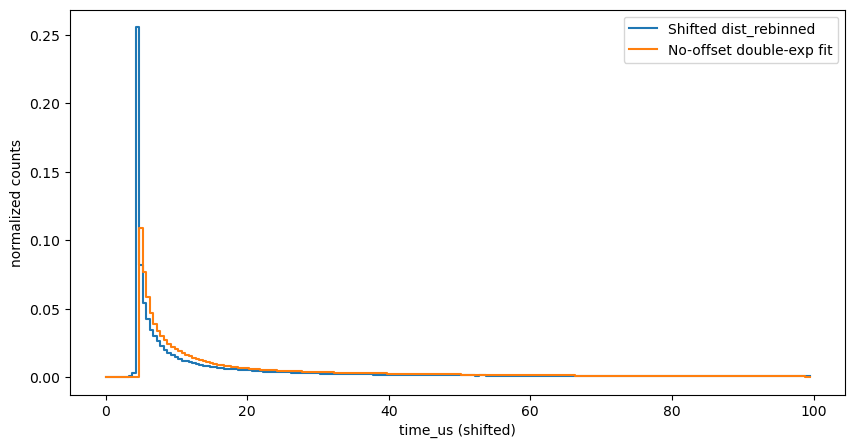

In [44]:
from scipy.optimize import curve_fit

def double_exp_no_offset(t, a, b, c, d, e, f, g, h, t_shift):
    res = a * np.exp(np.clip(b * t, -700, 700)) + c * np.exp(np.clip(d * t, -700, 700)) + e * np.exp(np.clip(f * t, -700, 700)) + g * np.exp(np.clip(h * t, -700, 700))
    return np.where(t > t_shift, res, 0)

# use C++-like initial guesses
p0 = [0.12074081, -1.54832358, 0.04136345, -1.5729156, 0.01, -0.1, 0.001, -0.1, 4.5]

lower_bounds = [0, -10, 0, -10, 0, -10, 0, -10, 4.]
upper_bounds = [10, 0, 10, 0, 10, 0, 10, 0, 5.]

popt, pcov = curve_fit(
    double_exp_no_offset,
    t_shifted,
    y_shifted,
    p0=p0,
    bounds=(lower_bounds, upper_bounds),
    maxfev=20000
)

print("Optimized no-offset parameters:", popt)

y_fit = double_exp_no_offset(t_shifted, *popt)

# normalize for shape comparison
y_fit = y_fit / y_fit.sum()

plt.figure(figsize=(10, 5))
plt.step(t_shifted, y_shifted, where='mid', label='Shifted dist_rebinned')
plt.step(t_shifted, y_fit, where='mid', label='No-offset double-exp fit')
plt.xlabel("time_us (shifted)")
plt.ylabel("normalized counts")
plt.legend()
# plt.yscale('log')
plt.show()

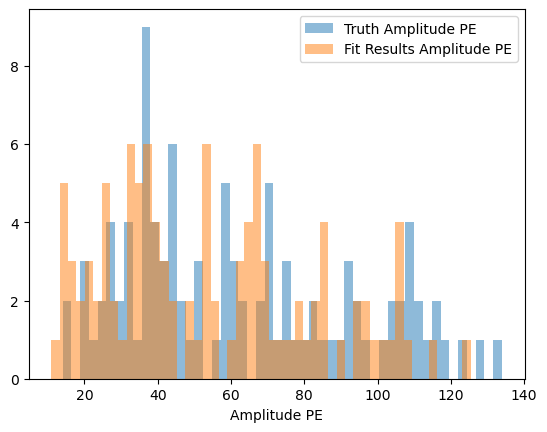

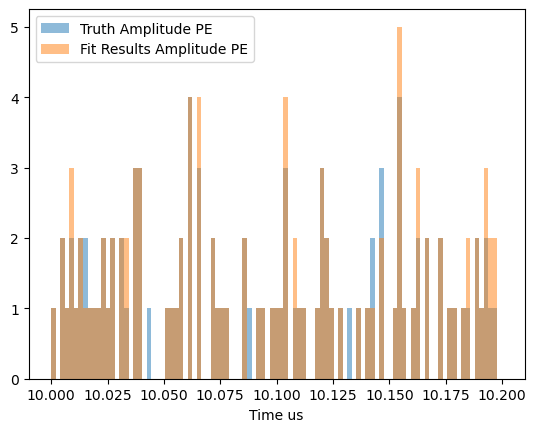

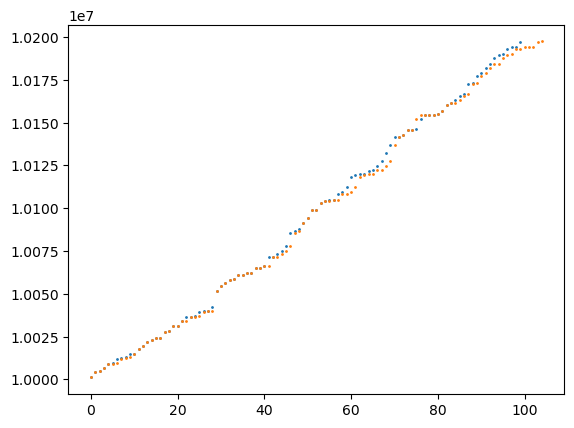

Truth time: 10001108.92 us, Fit time: 10001108.77 us
Truth time: 10004121.40 us, Fit time: 10004121.16 us
Truth time: 10005088.33 us, Fit time: 10005088.10 us
Truth time: 10006882.20 us, Fit time: 10006881.98 us
Truth time: 10009049.96 us, Fit time: 10009049.81 us
Truth time: 10009294.58 us, Fit time: 10009060.02 us
Truth time: 10011621.22 us, Fit time: 10009294.59 us
Truth time: 10012716.17 us, Fit time: 10011621.02 us
Truth time: 10013014.82 us, Fit time: 10012715.50 us
Truth time: 10014813.43 us, Fit time: 10013014.58 us
Truth time: 10014914.63 us, Fit time: 10014914.39 us
Truth time: 10017703.00 us, Fit time: 10017702.82 us
Truth time: 10019538.92 us, Fit time: 10019538.69 us
Truth time: 10021582.79 us, Fit time: 10021582.58 us
Truth time: 10023178.31 us, Fit time: 10023178.07 us
Truth time: 10023923.35 us, Fit time: 10023922.89 us
Truth time: 10024412.15 us, Fit time: 10024411.78 us
Truth time: 10027903.27 us, Fit time: 10027903.11 us
Truth time: 10028189.34 us, Fit time: 10028189

In [41]:
plt.hist(truth['amplitude_pe'], bins=50, alpha=0.5, label='Truth Amplitude PE')
plt.hist(fit_results['amplitude_pe'], bins=50, alpha=0.5, label='Fit Results Amplitude PE')
plt.legend()
plt.xlabel('Amplitude PE')
plt.show()

plt.hist(truth['time_us'] / 1e6, bins=np.linspace(10, 10.2, 100), alpha=0.5, label='Truth Amplitude PE')
plt.hist(fit_results['time_us'] / 1e6, bins=np.linspace(10, 10.2, 100), alpha=0.5, label='Fit Results Amplitude PE')
plt.legend()
plt.xlabel('Time us')
plt.show()

plt.scatter(range(len(truth['time_us'])), truth['time_us'], s=1)
plt.scatter(range(len(fit_results['time_us'])), fit_results['time_us'], s=1)
plt.show()

for i, j in zip(truth['time_us'], fit_results['time_us']):
    print(f"Truth time: {i:.2f} us, Fit time: {j:.2f} us")